In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("D:/DATA/aitpune/college study thingy/dsbdal/prac_exam_questions/2-linear_regression-coffee-shop/coffee_shop_revenue.csv")

df.head()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
0,152,6.74,14,4,106.62,97,1547.81
1,485,4.50,12,8,57.83,744,2084.68
2,398,9.09,6,6,91.76,636,3118.39
3,320,8.48,17,4,462.63,770,2912.20
4,156,7.44,17,2,412.52,232,1663.42


In [2]:
print("Columns:\n", df.columns)

# Dependent variable
y = df["Daily_Revenue"]

# Predictor variables
X = df.drop("Daily_Revenue", axis=1)

print("\nPredictors:\n", X.columns)
print("\nTarget: Daily_Revenue")

Columns:
 Index(['Number_of_Customers_Per_Day', 'Average_Order_Value',
       'Operating_Hours_Per_Day', 'Number_of_Employees',
       'Marketing_Spend_Per_Day', 'Location_Foot_Traffic', 'Daily_Revenue'],
      dtype='str')

Predictors:
 Index(['Number_of_Customers_Per_Day', 'Average_Order_Value',
       'Operating_Hours_Per_Day', 'Number_of_Employees',
       'Marketing_Spend_Per_Day', 'Location_Foot_Traffic'],
      dtype='str')

Target: Daily_Revenue


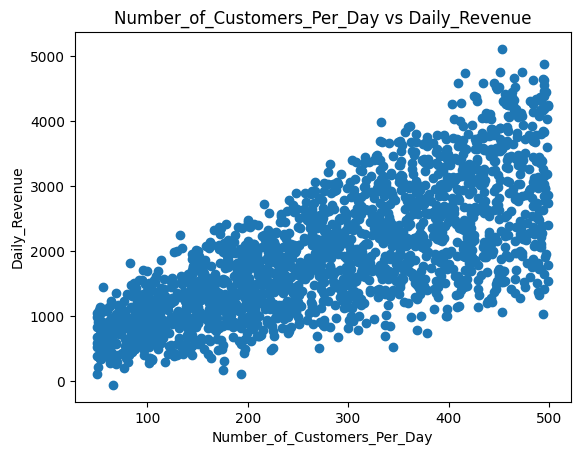

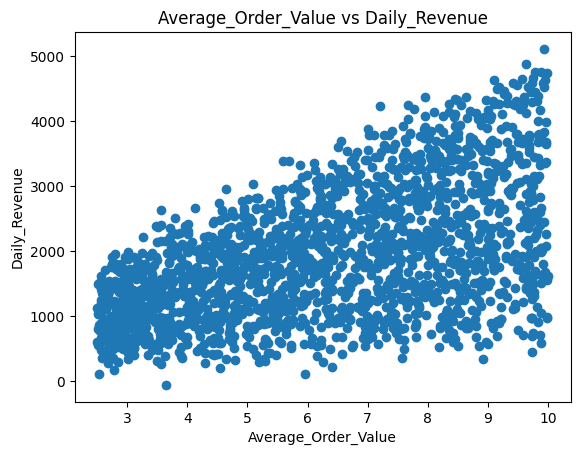

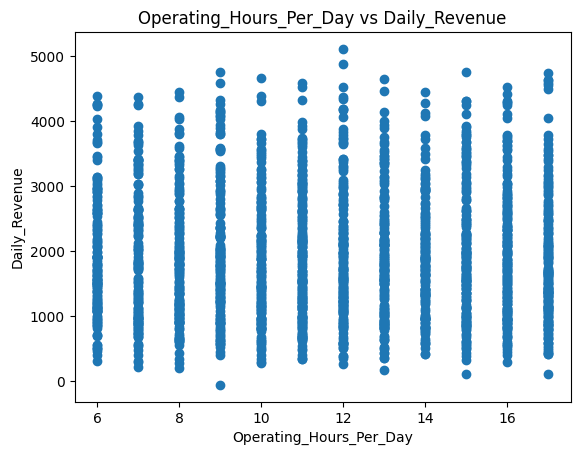

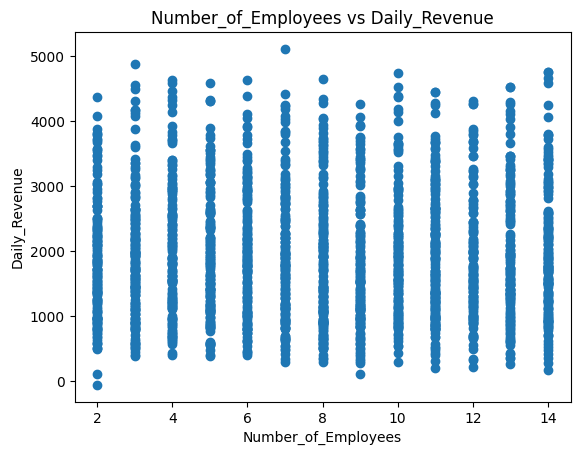

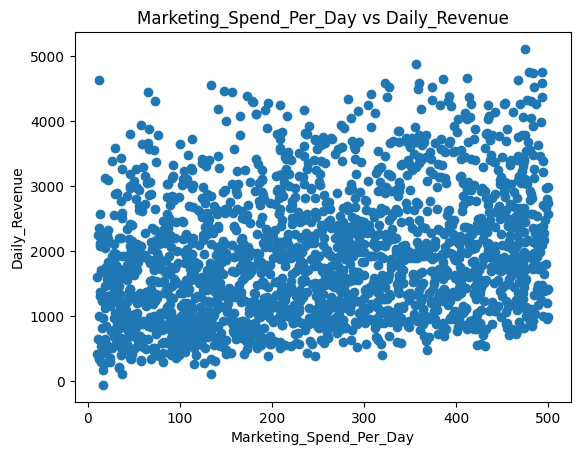

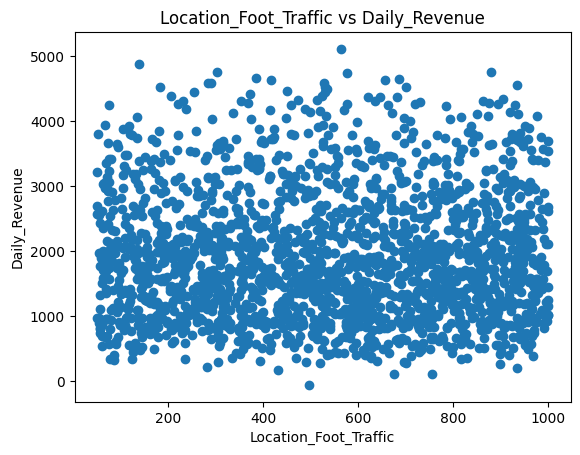

In [3]:
for col in X.columns:
    plt.figure()
    plt.scatter(df[col], df["Daily_Revenue"])
    plt.xlabel(col)
    plt.ylabel("Daily_Revenue")
    plt.title(f"{col} vs Daily_Revenue")
    plt.show()


--- Using Predictor: Number_of_Customers_Per_Day ---
MSE: 401391.8840212993
R2: 0.5704137785853378


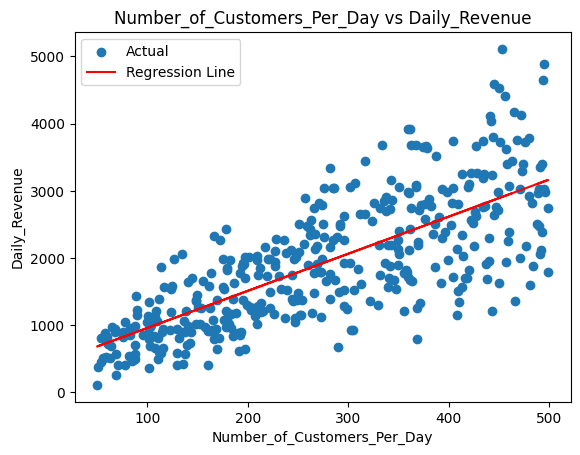


--- Using Predictor: Average_Order_Value ---
MSE: 678598.8131978735
R2: 0.2737354400452211


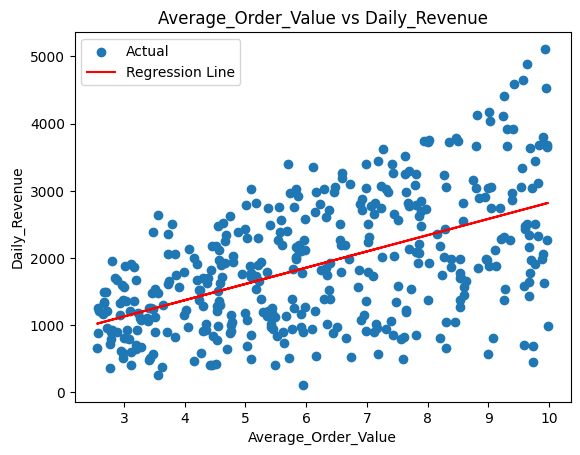


--- Using Predictor: Operating_Hours_Per_Day ---
MSE: 937296.5800141033
R2: -0.0031336262189547437


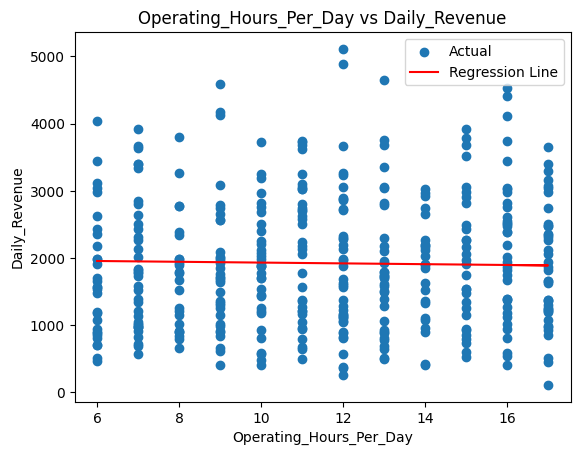


--- Using Predictor: Number_of_Employees ---
MSE: 936298.5289695181
R2: -0.0020654706480773832


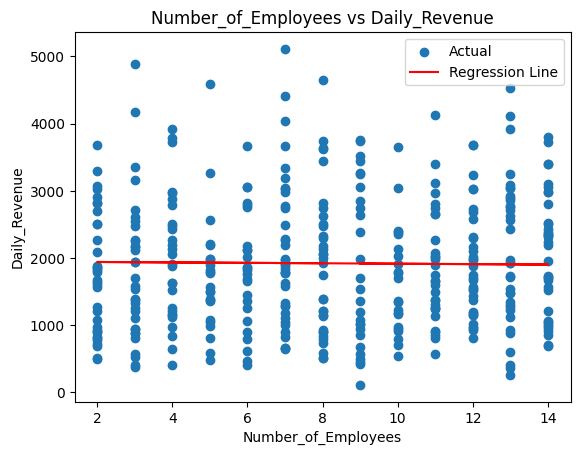


--- Using Predictor: Marketing_Spend_Per_Day ---
MSE: 870604.9771006438
R2: 0.06824248983166237


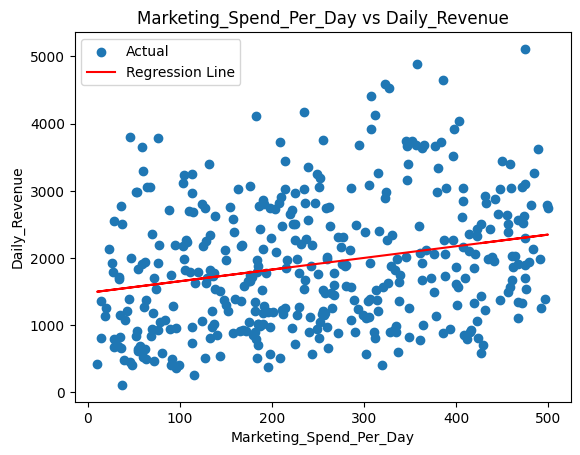


--- Using Predictor: Location_Foot_Traffic ---
MSE: 938385.1408802163
R2: -0.004298649150082268


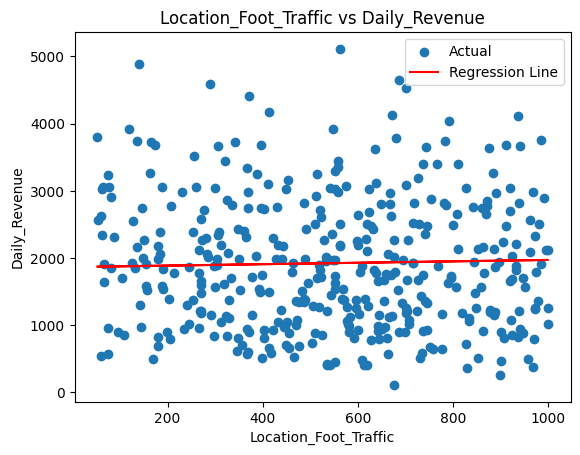

In [4]:

y = df["Daily_Revenue"]

for col in df.drop("Daily_Revenue", axis=1).columns:
    
    print(f"\n--- Using Predictor: {col} ---")
    
    X = df[[col]]
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Prediction
    y_pred = model.predict(X_test)
    
    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print("MSE:", mse)
    print("R2:", r2)
    
    # Plot
    plt.figure()
    plt.scatter(X_test, y_test, label="Actual")
    plt.plot(X_test, y_pred, color='red', label="Regression Line")
    
    plt.xlabel(col)
    plt.ylabel("Daily_Revenue")
    plt.title(f"{col} vs Daily_Revenue")
    plt.legend()
    
    plt.show()

In [5]:
X = df.drop("Daily_Revenue", axis=1)
y = df["Daily_Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)

In [19]:
mse_multi = mean_squared_error(y_test, y_pred_multi)

print("Simple MSE:", mse_simple)
print("Multiple MSE:", mse_multi)

Simple MSE: 401391.8840212993
Multiple MSE: 97569.72294013883


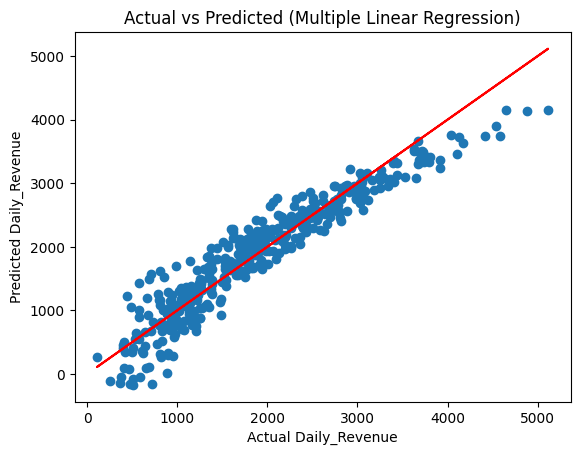

In [20]:
plt.figure()

plt.scatter(y_test, y_pred_multi)
plt.plot(y_test, y_test, color='red')

plt.xlabel("Actual Daily_Revenue")
plt.ylabel("Predicted Daily_Revenue")
plt.title("Actual vs Predicted (Multiple Linear Regression)")

plt.show()